Shape of dataset: (1000, 9)

Column Names:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows:
0

Basic Summary:
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.0

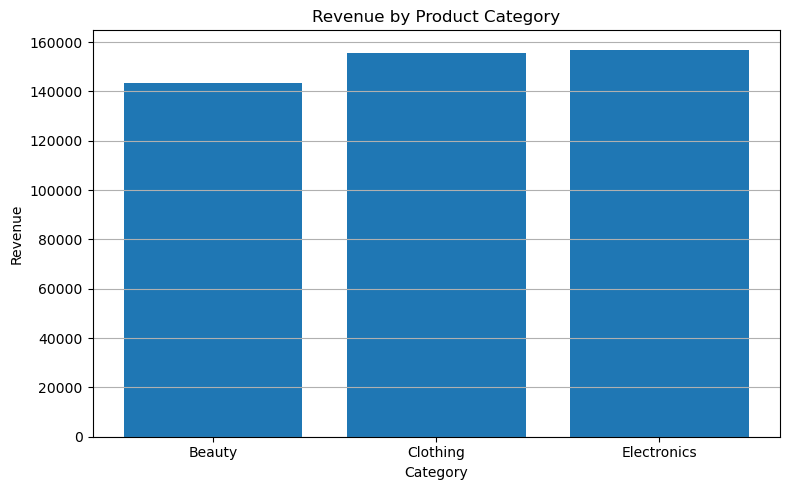



Gender wise revenue:
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

Female customers generated the highest revenue of 232840


Age group wise revenue:
Age_Group
18-25     73335
26-35     98480
36-45     91870
46+      181100
Name: Total Amount, dtype: int64

46+ age group generated the highest revenue of 181100


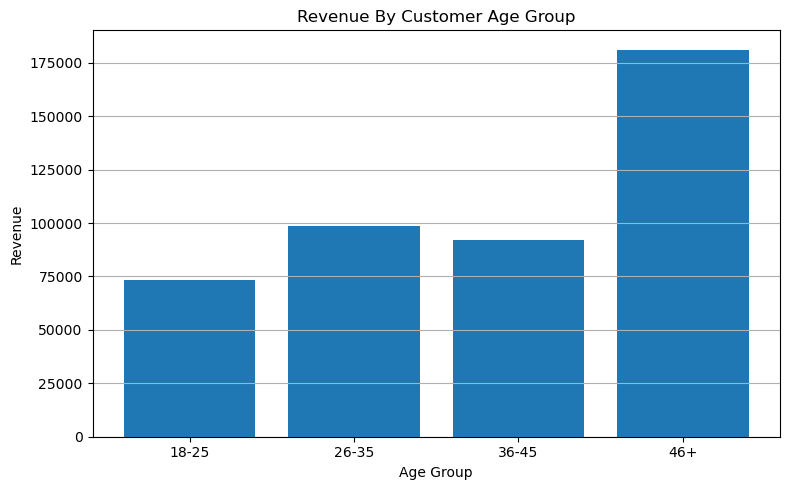

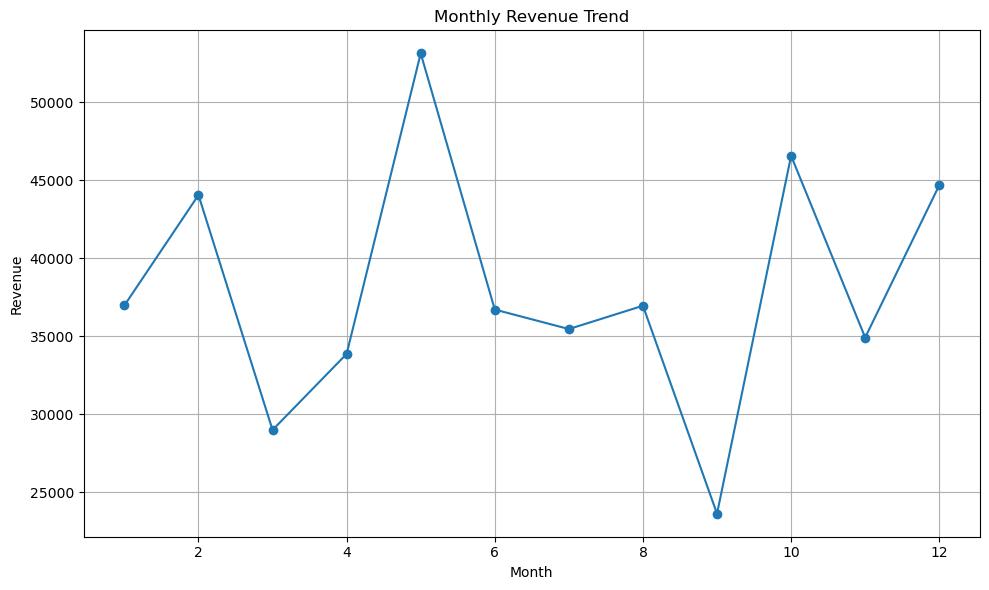


Revenue was not consistent throughout the year. May generated the highest revenue while September generated the lowest revenue, indicating fluctuations in customer purchasing behavior.


Day wise revenue:
Day
Monday       70250
Tuesday      69440
Wednesday    58770
Thursday     53835
Friday       66290
Saturday     78815
Sunday       58600
Name: Total Amount, dtype: int64

Best revenue day: Saturday
Worst revenue day: Thursday


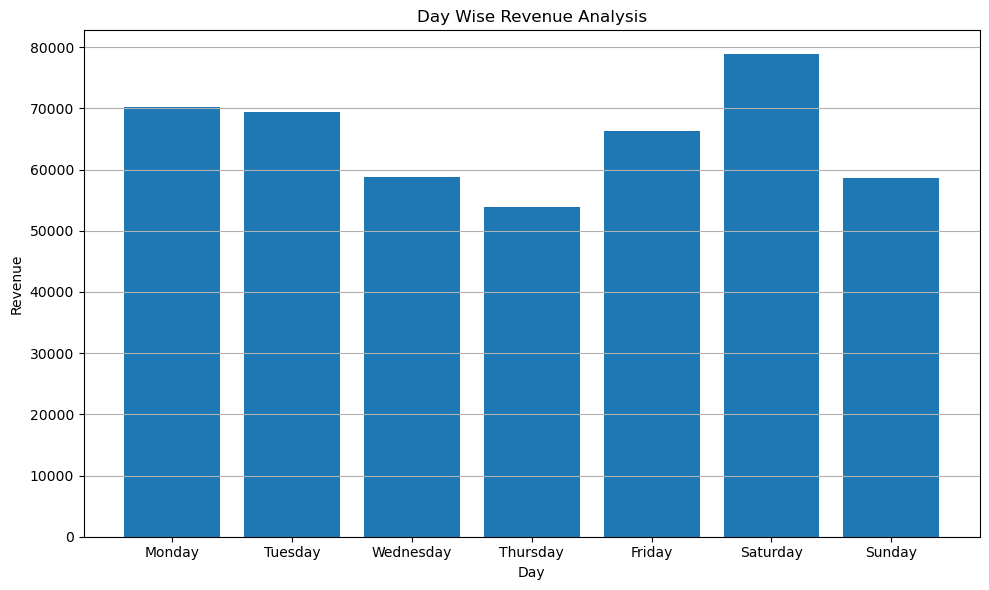

In [1]:
# ==================================
# Import libraries
# ==================================
import pandas as pd
import matplotlib.pyplot as plt


# ==================================
# Loading the given dataset
# ==================================
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\retail_sales_dataset.csv")


# ==================================
# Data inspection
# ==================================
print("Shape of dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nBasic Summary:")
print(df.describe())

print("\nData Info:")
df.info()


# ==================================
# Created new columns from Date column
# ==================================
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day_name()

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 45, 100],
    labels=["18-25", "26-35", "36-45", "46+"]
)


# ==================================
# Total revenue of company
# ==================================
total_revenue = df["Total Amount"].sum()
print("\n\nCompany's total revenue:", total_revenue)


# ==================================
# Monthly revenue
# ==================================
monthly_revenue = df.groupby("Month")["Total Amount"].sum()

month_names = df.drop_duplicates("Month").set_index("Month")["Month_Name"]

best_month = monthly_revenue.idxmax()
best_month_revenue = monthly_revenue.max()

worst_month = monthly_revenue.idxmin()
worst_month_revenue = monthly_revenue.min()

print("\n\nMonthly revenue:")
print(monthly_revenue)

print("\nBest month:", month_names[best_month])
print("Best month's revenue:", best_month_revenue)

print("\nWorst month:", month_names[worst_month])
print("Worst month's revenue:", worst_month_revenue)


# ==================================
# Finding top category
# ==================================
category_wise_revenue = df.groupby("Product Category")["Total Amount"].sum()

top_category = category_wise_revenue.idxmax()
top_category_revenue = category_wise_revenue.max()

print(
    "\n",
    top_category,
    "generated the highest revenue of",
    top_category_revenue,
    "among all product categories. This indicates strong customer spending in this category."
)


# ==================================
# Revenue by product Category
# ==================================
plt.figure(figsize=(8, 5))
plt.bar(category_wise_revenue.index, category_wise_revenue.values)
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.title("Revenue by Product Category")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


# ==================================
# Revenue By gender
# ==================================
gender_wise_revenue = df.groupby("Gender")["Total Amount"].sum()

highest_gender = gender_wise_revenue.idxmax()
highest_gender_revenue = gender_wise_revenue.max()

print("\n\nGender wise revenue:")
print(gender_wise_revenue)

print(
    f"\n{highest_gender} customers generated the highest revenue of {highest_gender_revenue}"
)


# ==================================
# Revenue analysis by Age
# ==================================
age_wise_revenue = df.groupby("Age_Group", observed=True)["Total Amount"].sum()

best_age_group = age_wise_revenue.idxmax()
best_age_group_revenue = age_wise_revenue.max()

print("\n\nAge group wise revenue:")
print(age_wise_revenue)

print(
    f"\n{best_age_group} age group generated the highest revenue of {best_age_group_revenue}"
)


# ==================================
# Revenue analysis chart by Age group
# ==================================
plt.figure(figsize=(8, 5))
plt.bar(age_wise_revenue.index.astype(str), age_wise_revenue.values)
plt.title("Revenue By Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


# ==================================
# Monthly revenue trend
# ==================================
plt.figure(figsize=(10, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.grid(True)
plt.tight_layout()
plt.show()

print(
    "\nRevenue was not consistent throughout the year. "
    f"{month_names[best_month]} generated the highest revenue while "
    f"{month_names[worst_month]} generated the lowest revenue, "
    "indicating fluctuations in customer purchasing behavior."
)


# ==================================
# Day wise revenue
# ==================================
day_wise_revenue = df.groupby("Day")["Total Amount"].sum()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_wise_revenue = day_wise_revenue.reindex(day_order)

best_revenue_day = day_wise_revenue.idxmax()
worst_revenue_day = day_wise_revenue.idxmin()

print("\n\nDay wise revenue:")
print(day_wise_revenue)

print("\nBest revenue day:", best_revenue_day)
print("Worst revenue day:", worst_revenue_day)

plt.figure(figsize=(10, 6))
plt.bar(day_wise_revenue.index, day_wise_revenue.values)
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.title("Day Wise Revenue Analysis")
plt.tight_layout()
plt.grid(axis="y")
plt.show()


# ==================================
# Quantity sold by product category
# ==================================
category_wise_quantity = df.groupby("Product Category")["Quantity"].sum()




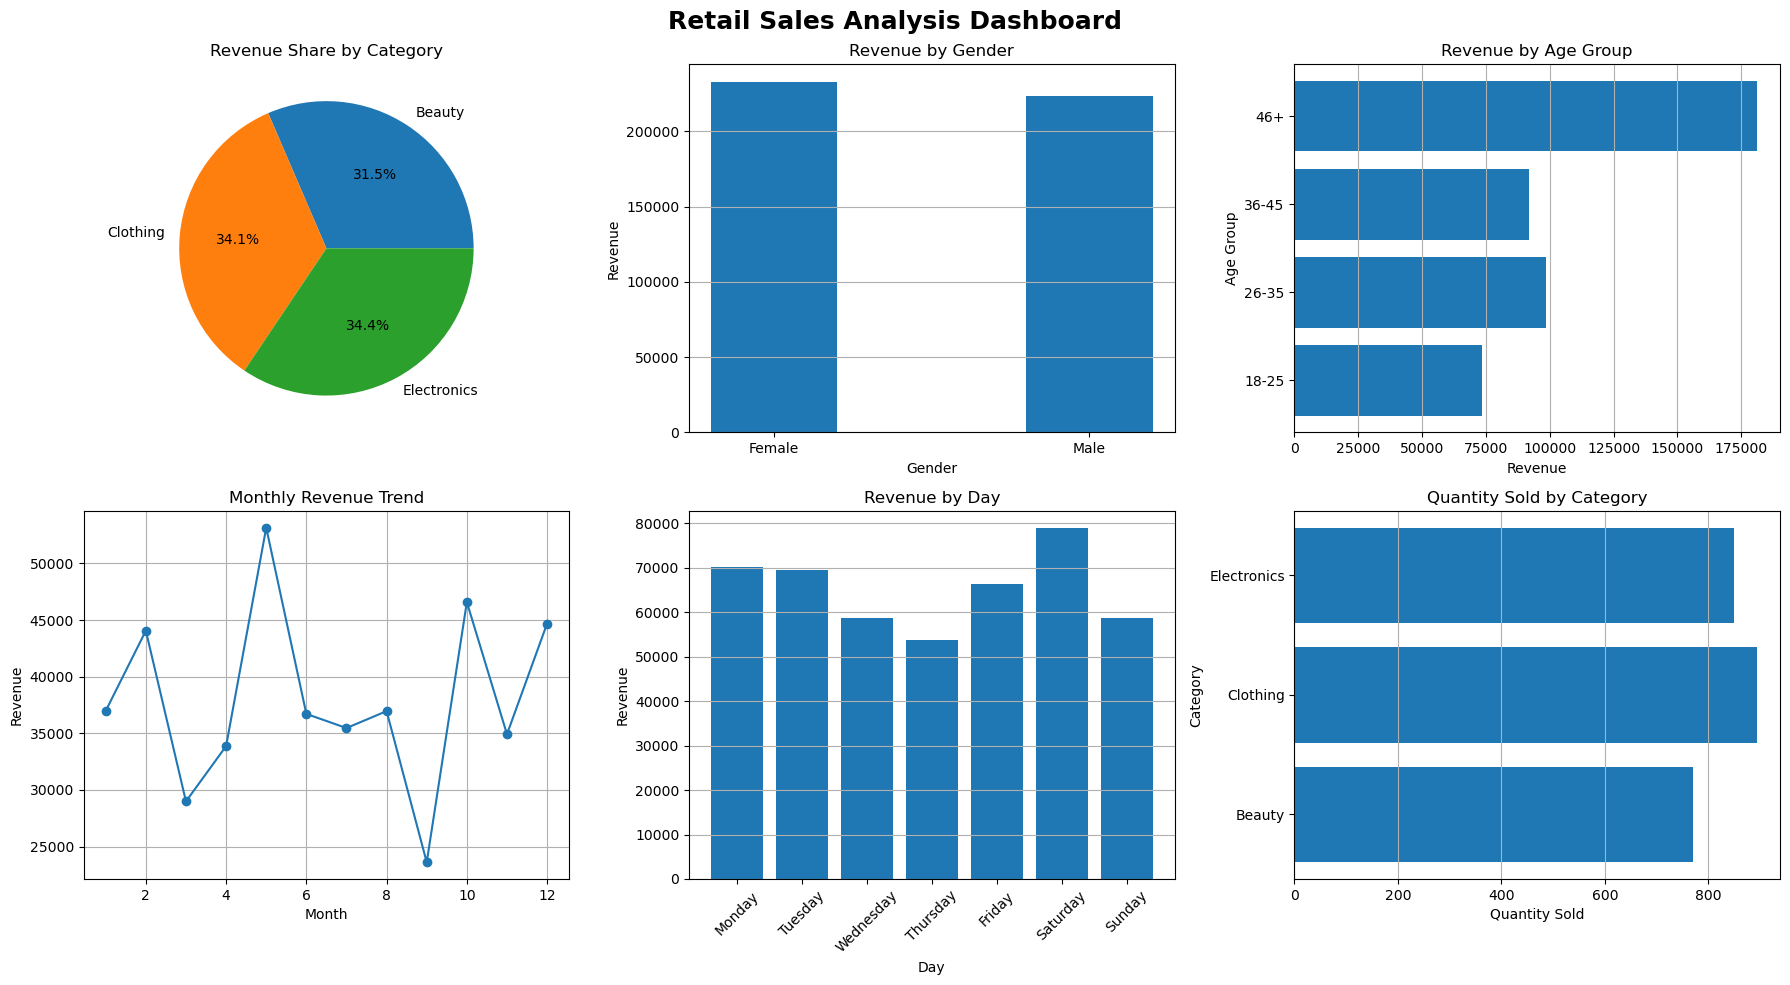

In [2]:
# ==================================
# LinkedIn Dashboard
# ==================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

fig.suptitle(
    "Retail Sales Analysis Dashboard",
    fontsize=18,
    fontweight="bold"
)

# ==================================
# 1. Revenue Share by Category
# ==================================

axes[0, 0].pie(
    category_wise_revenue.values,
    labels=category_wise_revenue.index,
    autopct="%1.1f%%"
)

axes[0, 0].set_title("Revenue Share by Category")


# ==================================
# 2. Revenue by Gender
# ==================================

axes[0, 1].bar(
    gender_wise_revenue.index,
    gender_wise_revenue.values,
    width=0.4
)

axes[0, 1].set_title("Revenue by Gender")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Revenue")
axes[0, 1].grid(axis="y")


# ==================================
# 3. Revenue by Age Group
# ==================================

axes[0, 2].barh(
    age_wise_revenue.index.astype(str),
    age_wise_revenue.values
)

axes[0, 2].set_title("Revenue by Age Group")
axes[0, 2].set_xlabel("Revenue")
axes[0, 2].set_ylabel("Age Group")
axes[0, 2].grid(axis="x")


# ==================================
# 4. Monthly Revenue Trend
# ==================================

axes[1, 0].plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

axes[1, 0].set_title("Monthly Revenue Trend")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].grid(True)


# ==================================
# 5. Revenue by Day
# ==================================

axes[1, 1].bar(
    day_wise_revenue.index,
    day_wise_revenue.values
)

axes[1, 1].set_title("Revenue by Day")
axes[1, 1].set_xlabel("Day")
axes[1, 1].set_ylabel("Revenue")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y")


# ==================================
# 6. Quantity Sold by Category
# ==================================

axes[1, 2].barh(
    category_wise_quantity.index,
    category_wise_quantity.values
)

axes[1, 2].set_title("Quantity Sold by Category")
axes[1, 2].set_xlabel("Quantity Sold")
axes[1, 2].set_ylabel("Category")
axes[1, 2].grid(axis="x")


# ==================================
# Save Dashboard
# ==================================

plt.tight_layout()

plt.savefig(
    "retail_sales_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()